## Import Libraries

In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import os
import sys
sys.path.append('..')
from src.parser import ResumeParser
from src.preprocess import TextPreprocessor
from src.similarity import SimilarityCalculator
from src.ranking import CandidateRanker
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Load Dataset

In [2]:
# Load Dataset Information

# Define paths
resume_dir = '../data/resumes/'
jd_dir = '../data/job_descriptions/'
processed_dir = '../data/processed/'

# Create directories if they don't exist
os.makedirs(resume_dir, exist_ok=True)
os.makedirs(jd_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)
os.makedirs('../output/charts/', exist_ok=True)

print(f"Resume Directory: {resume_dir}")
print(f"Job Description Directory: {jd_dir}")

# Count files
resume_files = [f for f in os.listdir(resume_dir) if f.endswith('.pdf')]
jd_files = [f for f in os.listdir(jd_dir) if f.endswith('.txt')]

print(f"Found {len(resume_files)} resumes")
print(f"Found {len(jd_files)} job descriptions")

Resume Directory: ../data/resumes/
Job Description Directory: ../data/job_descriptions/
Found 40 resumes
Found 5 job descriptions


In [3]:
# Read Sample Resume

# Initialize parser
parser = ResumeParser()

# Read a sample resume
if resume_files:
    sample_resume = resume_files[0]
    sample_path = os.path.join(resume_dir, sample_resume)

    # Extract text
    resume_text = parser.extract_text(sample_path)
    print(f"Sample Resume: {sample_resume}")
    print(f"Text length: {len(resume_text)} characters")
    print("\nFirst 500 characters:")
    print(resume_text[:500])
    print("\n...")


Sample Resume: Adeel_Abbasi_Backend_Developer_3.pdf
Text length: 880 characters

First 500 characters:
Adeel Abbasi
API Developer | Faisalabad, Pakistan
Email: adeel.abbasi@example.com | Phone: 0385-7851696
SUMMARY
API Developer with 5 year(s) of experience in backend developer roles. Skilled in Express.js, SQL,
Docker and passionate about building scalable, user-focused applications.
SKILLS
Express.js, SQL, Docker, Django, Flask, Node.js, Git, MongoDB, Microservices, REST API, Redis,
AWS, Python, PostgreSQL
EXPERIENCE
API Developer - CodeCrafters (Faisalabad)
Duration: 5 year(s)
- Worked on Paym

...


In [4]:
#  Extract Resume Names

def extract_candidate_name(text):
    """Extract candidate name from resume text"""
    # Simple pattern - look for common name patterns
    lines = text.split('\n')
    for line in lines[:10]:  # Check first 10 lines
        line = line.strip()
        if line and len(line) < 50 and not any(keyword in line.lower() for keyword in
                                                 ['resume', 'curriculum', 'vitae', 'contact', 'email']):
            # Check if it contains at least two words
            words = line.split()
            if 2 <= len(words) <= 4:
                return line
    return "Unknown"

resume_names = []
for resume_file in resume_files[:10]:  # First 10 for analysis
    path = os.path.join(resume_dir, resume_file)
    text = parser.extract_text(path)
    name = extract_candidate_name(text)
    resume_names.append({
        'file': resume_file,
        'name': name,
        'text_length': len(text)
    })

df_samples = pd.DataFrame(resume_names)
df_samples.head()


,file,name,text_length
0,Adeel_Abbasi_Backend_Developer_3.pdf,Adeel Abbasi,880
1,Adeel_Malik_Data_Scientist_6.pdf,Adeel Malik,970
2,Ali_Abbasi_MERN_Developer_7.pdf,Ali Abbasi,884
3,Anum_Awan_Frontend_Developer_4.pdf,Anum Awan,856
4,Ayesha_Khan_MERN_Developer_3.pdf,Ayesha Khan,884


In [5]:
# Analyze Text Statistics

# Read all resumes for analysis
all_resumes_text = []
for resume_file in resume_files:
    path = os.path.join(resume_dir, resume_file)
    text = parser.extract_text(path)
    all_resumes_text.append(text)

# Create DataFrame with statistics
stats = pd.DataFrame({
    'filename': resume_files,
    'char_length': [len(t) for t in all_resumes_text],
    'word_count': [len(t.split()) for t in all_resumes_text],
})

# Add sample content
stats['preview'] = [t[:100] + '...' for t in all_resumes_text]

stats.head()


,filename,char_length,word_count,preview
0,Adeel_Abbasi_Backend_Developer_3.pdf,880,118,"Adeel Abbasi\nAPI Developer | Faisalabad, Paki..."
1,Adeel_Malik_Data_Scientist_6.pdf,970,127,Adeel Malik\nMachine Learning Engineer | Multa...
2,Ali_Abbasi_MERN_Developer_7.pdf,884,117,Ali Abbasi\nFull Stack JavaScript Developer | ...
3,Anum_Awan_Frontend_Developer_4.pdf,856,114,"Anum Awan\nFrontend Developer | Multan, Pakist..."
4,Ayesha_Khan_MERN_Developer_3.pdf,884,120,"Ayesha Khan\nMERN Stack Developer | Karachi, P..."


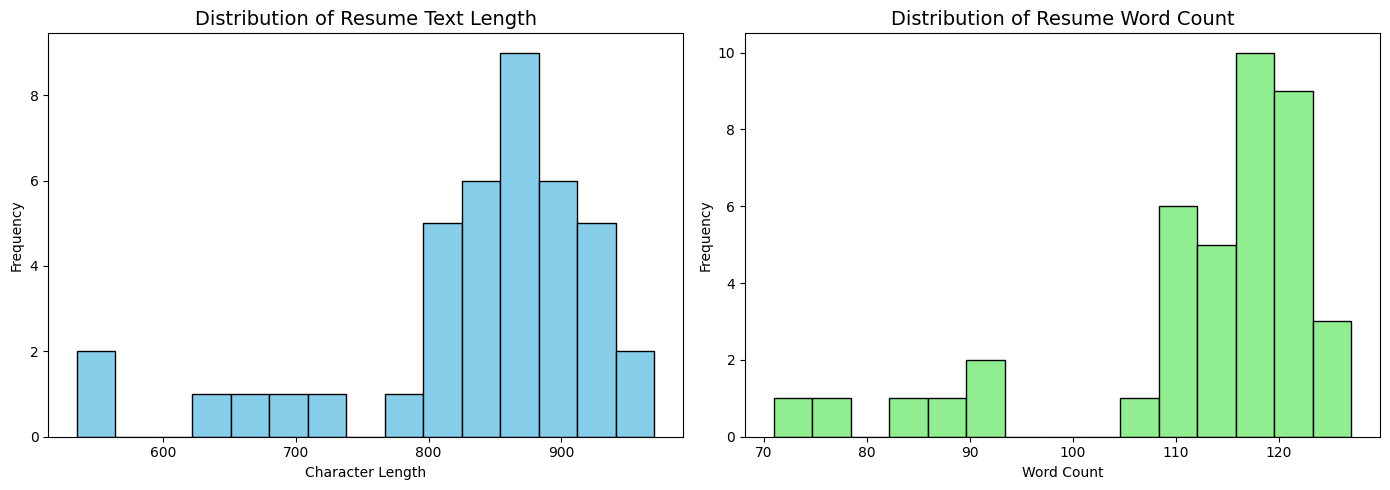

Average resume length: 837 characters
Average word count: 112 words


In [6]:
#  Visualize Text Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(stats['char_length'], bins=15, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Resume Text Length', fontsize=14)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')

# Word count distribution
axes[1].hist(stats['word_count'], bins=15, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Resume Word Count', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../images/resume_stats.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average resume length: {stats['char_length'].mean():.0f} characters")
print(f"Average word count: {stats['word_count'].mean():.0f} words")


In [7]:
# Read Job Descriptions

jd_texts = {}
jd_info = []

for jd_file in jd_files:
    path = os.path.join(jd_dir, jd_file)
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
    jd_texts[jd_file] = text
    jd_info.append({
        'file': jd_file,
        'title': jd_file.replace('_', ' ').replace('.txt', '').title(),
        'length': len(text),
        'words': len(text.split())
    })

jd_df = pd.DataFrame(jd_info)
jd_df

,file,title,length,words
0,Backend_Developer_JD.txt,Backend Developer Jd,964,126
1,Data_Scientist_JD.txt,Data Scientist Jd,956,125
2,Frontend_Developer_JD.txt,Frontend Developer Jd,972,125
3,MERN_Developer_JD.txt,Mern Developer Jd,993,129
4,UIUX_Designer_JD.txt,Uiux Designer Jd,984,126


In [8]:
#  Clean and Preprocess Sample
preprocessor = TextPreprocessor()

# Sample text for demonstration
sample_text = "As a skilled Data Scientist with 5 years of experience in machine learning, I have worked on various projects including predictive modeling and NLP."

print("Original Text:")
print(sample_text)
print("\n" + "="*50 + "\n")

# Clean text
cleaned = preprocessor.clean_text(sample_text)
print("Cleaned Text:")
print(cleaned)
print("\n" + "="*50 + "\n")

# Tokenize
tokens = preprocessor.tokenize(cleaned)
print(f"Tokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")
print("\n" + "="*50 + "\n")

# Remove stopwords
filtered = preprocessor.remove_stopwords(tokens)
print(f"After removing stopwords: {filtered}")
print(f"Number of tokens: {len(filtered)}")
print("\n" + "="*50 + "\n")

# Lemmatize
lemmatized = preprocessor.lemmatize(filtered)
print(f"After lemmatization: {lemmatized}")


Original Text:
As a skilled Data Scientist with 5 years of experience in machine learning, I have worked on various projects including predictive modeling and NLP.


Cleaned Text:
as a skilled data scientist with years of experience in machine learning i have worked on various projects including predictive modeling and nlp


Tokens: ['as', 'a', 'skilled', 'data', 'scientist', 'with', 'years', 'of', 'experience', 'in', 'machine', 'learning', 'i', 'have', 'worked', 'on', 'various', 'projects', 'including', 'predictive', 'modeling', 'and', 'nlp']
Number of tokens: 23


After removing stopwords: ['skilled', 'data', 'scientist', 'years', 'machine', 'learning', 'worked', 'various', 'projects', 'including', 'predictive', 'modeling', 'nlp']
Number of tokens: 13


After lemmatization: ['skilled', 'data', 'scientist', 'year', 'machine', 'learning', 'worked', 'various', 'project', 'including', 'predictive', 'modeling', 'nlp']


In [9]:
#  Process All Resumes
processed_resumes = []
for resume_file in resume_files:
    path = os.path.join(resume_dir, resume_file)
    text = parser.extract_text(path)

    # Clean and process
    cleaned_text = preprocessor.clean_text(text)
    tokens = preprocessor.tokenize(cleaned_text)
    filtered_tokens = preprocessor.remove_stopwords(tokens)
    lemmatized_tokens = preprocessor.lemmatize(filtered_tokens)

    # Store
    processed_resumes.append({
        'file': resume_file,
        'original_text': text,
        'cleaned_text': cleaned_text,
        'tokens': lemmatized_tokens,
        'token_count': len(lemmatized_tokens)
    })

print(f"Processed {len(processed_resumes)} resumes")


Processed 40 resumes


In [10]:
# Process Job Descriptions

processed_jds = []
for jd_file in jd_files:
    text = jd_texts[jd_file]

    # Clean and process
    cleaned_text = preprocessor.clean_text(text)
    tokens = preprocessor.tokenize(cleaned_text)
    filtered_tokens = preprocessor.remove_stopwords(tokens)
    lemmatized_tokens = preprocessor.lemmatize(filtered_tokens)

    processed_jds.append({
        'file': jd_file,
        'original_text': text,
        'cleaned_text': cleaned_text,
        'tokens': lemmatized_tokens,
        'token_count': len(lemmatized_tokens)
    })

print(f"Processed {len(processed_jds)} job descriptions")


Processed 5 job descriptions


In [11]:
#  Analyze Common Skills (Word Frequency)

from collections import Counter

# Get all tokens from resumes
all_tokens = []
for resume in processed_resumes:
    all_tokens.extend(resume['tokens'])

# Most common words
word_freq = Counter(all_tokens)
common_words = word_freq.most_common(20)

common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
common_df

,Word,Frequency
0,developer,95
1,year,74
2,j,68
3,system,58
4,user,52
5,application,48
6,design,46
7,data,43
8,code,41
9,pakistan,40


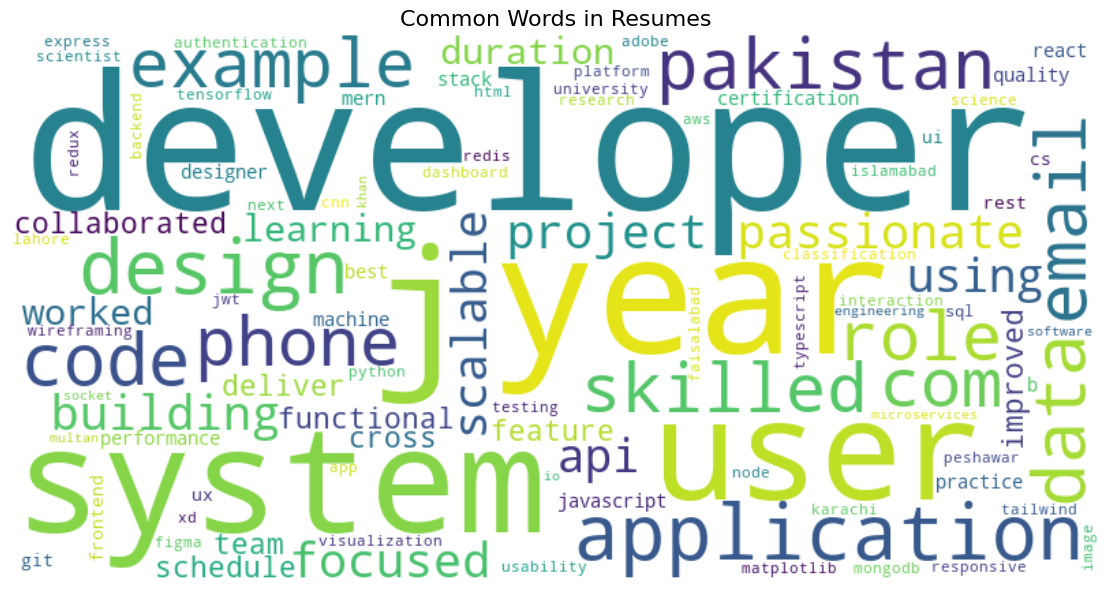

In [12]:
# Word Cloud Visualization
from wordcloud import WordCloud

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                     max_words=100).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Resumes', fontsize=16)
plt.tight_layout()
plt.savefig('../images/resume_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
#  Define Skill Keywords

# Common tech skills for different roles
skill_categories = {
    'Programming Languages': ['python', 'java', 'javascript', 'c++', 'c#', 'ruby', 'php', 'swift', 'kotlin', 'go'],
    'Frameworks & Libraries': ['react', 'angular', 'vue', 'django', 'flask', 'spring', 'node', 'express', 'tensorflow', 'pytorch'],
    'Data Science': ['machine learning', 'deep learning', 'nlp', 'computer vision', 'data analysis', 'statistics', 'sql'],
    'Web Development': ['html', 'css', 'frontend', 'backend', 'fullstack', 'rest api', 'graphql', 'aws'],
    'Database': ['mysql', 'postgresql', 'mongodb', 'redis', 'elasticsearch', 'sql server'],
    'Tools': ['git', 'docker', 'kubernetes', 'jenkins', 'jira', 'linux', 'aws', 'azure']
}

# Flatten skills for keyword matching
all_skills = [skill.lower() for skills in skill_categories.values() for skill in skills]

print(f"Total skills defined: {len(all_skills)}")
print("\nSample skills:", all_skills[:10])


Total skills defined: 49

Sample skills: ['python', 'java', 'javascript', 'c++', 'c#', 'ruby', 'php', 'swift', 'kotlin', 'go']


In [14]:
# Skill Extraction from Resumes

def extract_skills(text_tokens):
    """Extract skills from tokenized text"""
    found_skills = []
    text_lower = ' '.join(text_tokens).lower()

    for skill in all_skills:
        if skill in text_lower:
            found_skills.append(skill)

    return found_skills

# Extract skills from all resumes
resume_skills = []
for resume in processed_resumes:
    skills = extract_skills(resume['tokens'])
    resume_skills.append({
        'file': resume['file'],
        'skills': skills,
        'skill_count': len(skills)
    })

skill_df = pd.DataFrame(resume_skills)
skill_df.head()


,file,skills,skill_count
0,Adeel_Abbasi_Backend_Developer_3.pdf,"[python, go, django, flask, node, express, sql...",16
1,Adeel_Malik_Data_Scientist_6.pdf,"[python, tensorflow, machine learning, deep le...",6
2,Ali_Abbasi_MERN_Developer_7.pdf,"[java, javascript, go, node, express, rest api...",8
3,Anum_Awan_Frontend_Developer_4.pdf,"[java, javascript, react, frontend]",4
4,Ayesha_Khan_MERN_Developer_3.pdf,"[java, javascript, go, node, express, rest api...",7


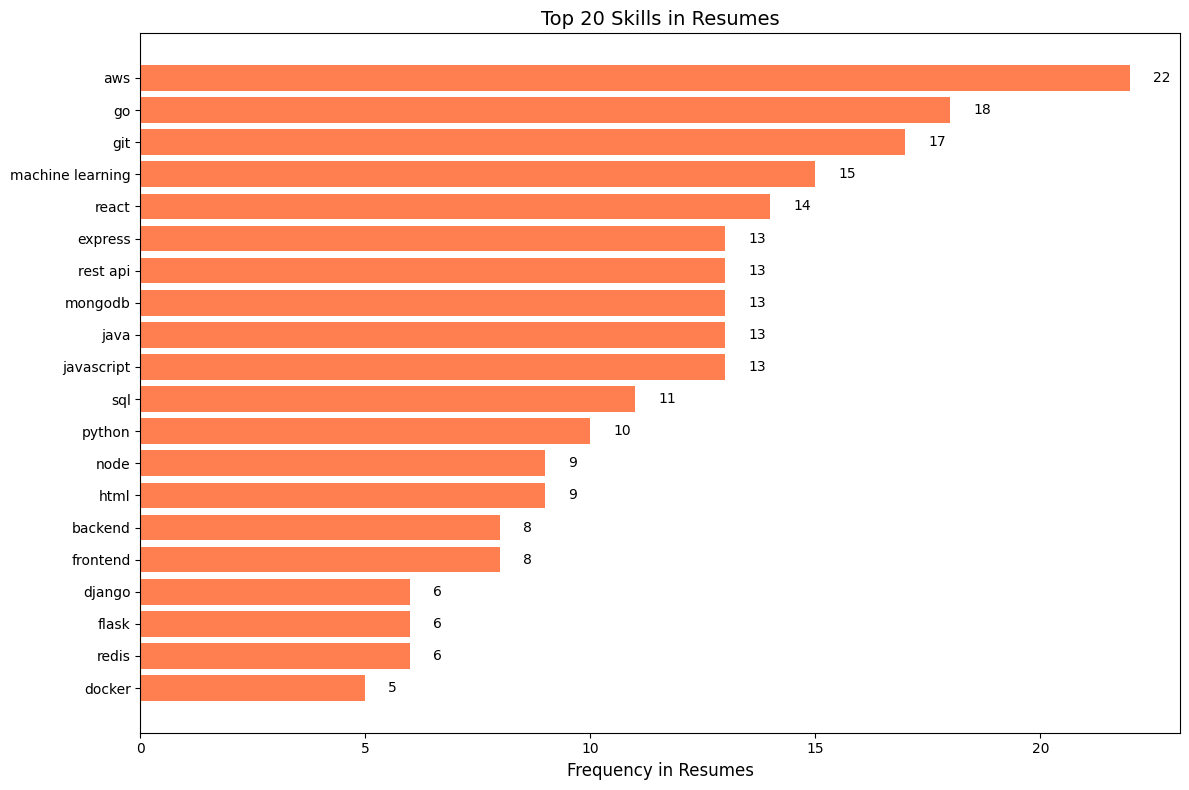

In [15]:
#  Skills Visualization

# Count skills across all resumes
skill_counts = Counter()
for r in resume_skills:
    skill_counts.update(r['skills'])

# Top 20 skills
top_skills = skill_counts.most_common(20)
top_skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_skills_df['Skill'], top_skills_df['Count'], color='coral')
ax.set_xlabel('Frequency in Resumes', fontsize=12)
ax.set_title('Top 20 Skills in Resumes', fontsize=14)
ax.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/top_skills.png', dpi=300, bbox_inches='tight')
plt.show()